In [ ]:
!pip install -q kaggle

import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_d90f11e9d95f428ab273bab824d60491"

!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

!kaggle competitions list
!kaggle datasets download -d puneet6060/intel-image-classification

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [ ]:
!unzip -oq intel-image-classification.zip -d /content/intel
!find /content/intel -type d | head -30
!ls /content/intel

/content/intel
/content/intel/seg_pred
/content/intel/seg_pred/seg_pred
/content/intel/seg_test
/content/intel/seg_test/seg_test
/content/intel/seg_test/seg_test/glacier
/content/intel/seg_test/seg_test/sea
/content/intel/seg_test/seg_test/buildings
/content/intel/seg_test/seg_test/mountain
/content/intel/seg_test/seg_test/forest
/content/intel/seg_test/seg_test/street
/content/intel/seg_train
/content/intel/seg_train/seg_train
/content/intel/seg_train/seg_train/glacier
/content/intel/seg_train/seg_train/sea
/content/intel/seg_train/seg_train/buildings
/content/intel/seg_train/seg_train/mountain
/content/intel/seg_train/seg_train/forest
/content/intel/seg_train/seg_train/street
seg_pred  seg_test  seg_train


In [ ]:
!pip install -q tensorflow gradio opencv-python seaborn scikit-learn matplotlib pillow

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
!unzip -oq intel-image-classification.zip -d /content/intel

In [ ]:
!find /content/intel -type d | head -30

/content/intel
/content/intel/seg_pred
/content/intel/seg_pred/seg_pred
/content/intel/seg_test
/content/intel/seg_test/seg_test
/content/intel/seg_test/seg_test/glacier
/content/intel/seg_test/seg_test/sea
/content/intel/seg_test/seg_test/buildings
/content/intel/seg_test/seg_test/mountain
/content/intel/seg_test/seg_test/forest
/content/intel/seg_test/seg_test/street
/content/intel/seg_train
/content/intel/seg_train/seg_train
/content/intel/seg_train/seg_train/glacier
/content/intel/seg_train/seg_train/sea
/content/intel/seg_train/seg_train/buildings
/content/intel/seg_train/seg_train/mountain
/content/intel/seg_train/seg_train/forest
/content/intel/seg_train/seg_train/street


In [ ]:
TRAIN_DIR = "/content/intel/seg_train/seg_train"
TEST_DIR = "/content/intel/seg_test/seg_test"
PRED_DIR = "/content/intel/seg_pred/seg_pred"

In [ ]:
print(os.listdir(TRAIN_DIR))


['glacier', 'sea', 'buildings', 'mountain', 'forest', 'street']


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 11230 images belonging to 6 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2804 images belonging to 6 classes.


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.4)(x)

output = Dense(
    6,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(6, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()
print(model.optimizer)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1248s 4s/step - accuracy: 0.1758 - loss: 1.7990 - val_accuracy: 0.1790 - val_loss: 1.7910
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1298s 4s/step - accuracy: 0.1796 - loss: 1.7912 - val_accuracy: 0.1790 - val_loss: 1.7908
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1223s 3s/step - accuracy: 0.1790 - loss: 1.7909 - val_accuracy: 0.1790 - val_loss: 1.7908
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1226s 3s/step - accuracy: 0.1790 - loss: 1.7909 - val_accuracy: 0.1790 - val_loss: 1.7908
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1241s 4s/step - accuracy: 0.1790 - loss: 1.7909 - val_accuracy: 0.1790 - val_loss: 1.7908
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1213s 3s/step - accuracy: 0.1790 - loss: 1.7909 - val_accuracy: 0.1790 - val_loss: 1.7908
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1198s 3s/step - accuracy: 0.1790 - loss: 1.7909 - val_accuracy: 0.1790 - val_loss: 1.7908
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 1180s 3s/step - accuracy: 0.1790 - loss: 1.7909 - 

In [ ]:
model.save("scenesense_model.h5")

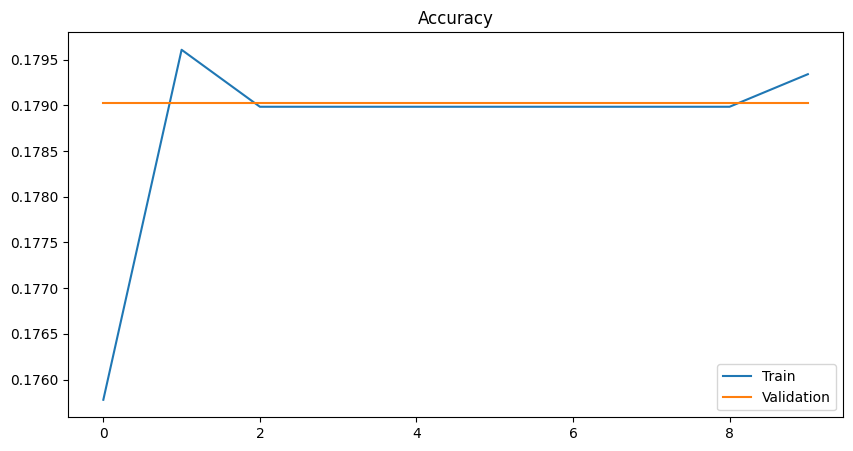

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

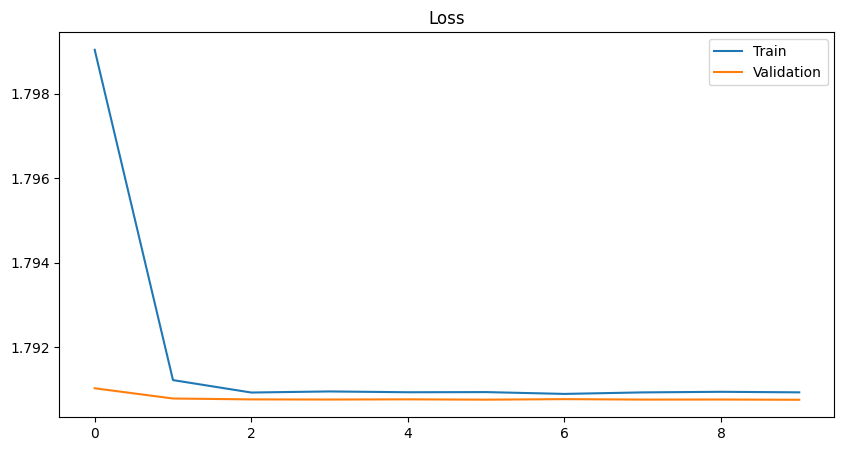

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
loss, acc = model.evaluate(val_generator)

print("Validation Accuracy:", acc)

88/88 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step - accuracy: 0.1790 - loss: 1.7908
Validation Accuracy: 0.17902995645999908


88/88 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step


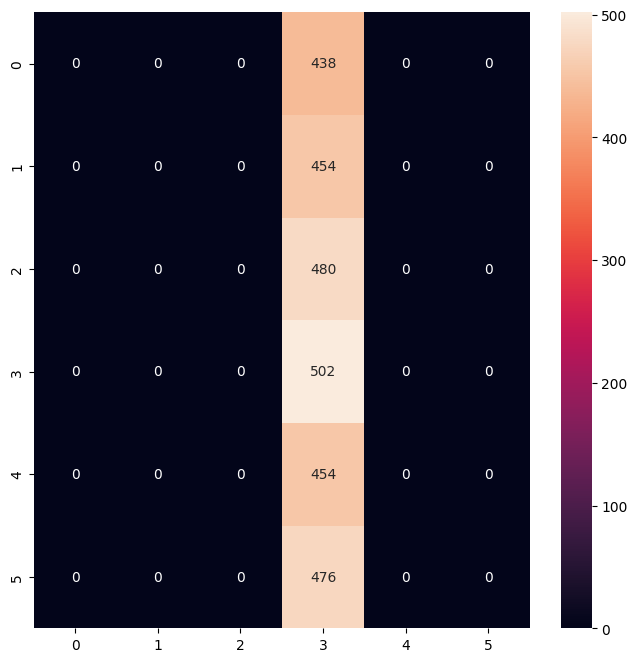

In [ ]:
preds = model.predict(val_generator)

pred_classes = np.argmax(preds, axis=1)

true_classes = val_generator.classes
cm = confusion_matrix(
    true_classes,
    pred_classes[:len(true_classes)]
)

plt.figure(figsize=(8,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

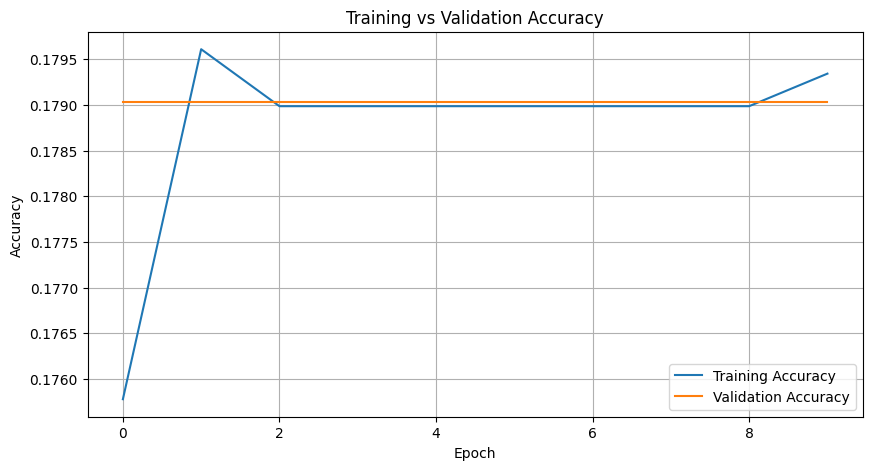

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.savefig('accuracy_graph.png')
plt.show()

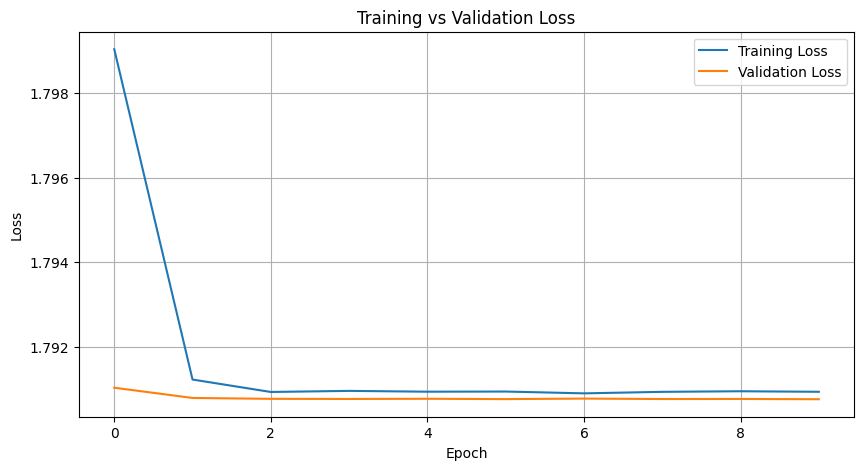

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.savefig('loss_graph.png')
plt.show()

88/88 ━━━━━━━━━━━━━━━━━━━━ 238s 3s/step


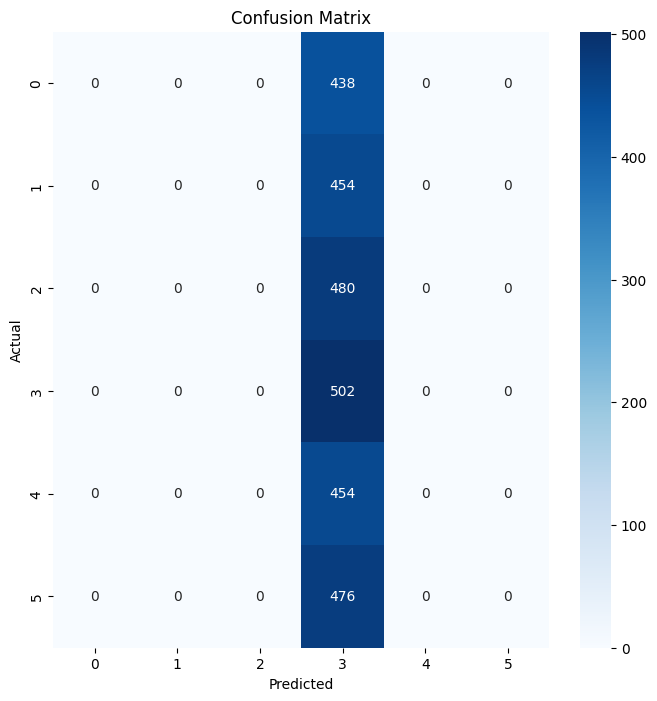

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(val_generator)

predicted_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(
    val_generator.classes,
    predicted_classes[:len(val_generator.classes)]
)

plt.figure(figsize=(8,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig('confusion_matrix.png')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        val_generator.classes,
        predicted_classes[:len(val_generator.classes)]
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       438
           1       0.00      0.00      0.00       454
           2       0.00      0.00      0.00       480
           3       0.18      1.00      0.30       502
           4       0.00      0.00      0.00       454
           5       0.00      0.00      0.00       476

    accuracy                           0.18      2804
   macro avg       0.03      0.17      0.05      2804
weighted avg       0.03      0.18      0.05      2804



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
Prediction Vector:
[[0.15598688 0.16205105 0.17169327 0.1792059  0.16129947 0.16976343]]
Predicted Class: 3
Confidence: 0.1792059
Using Layer: top_activation


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_242']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Gradient Shape: (1, 7, 7, 1280)
Heatmap Min: 0.0
Heatmap Max: 0.0


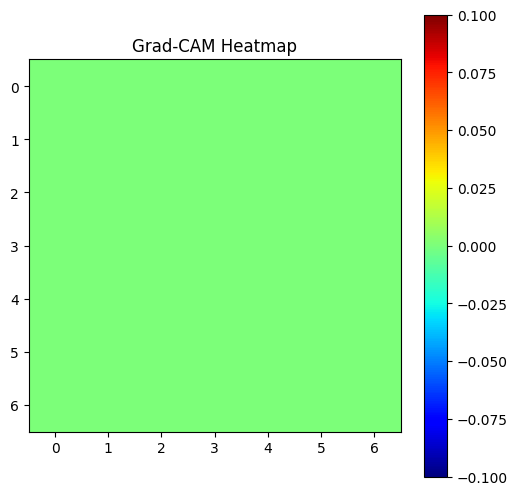

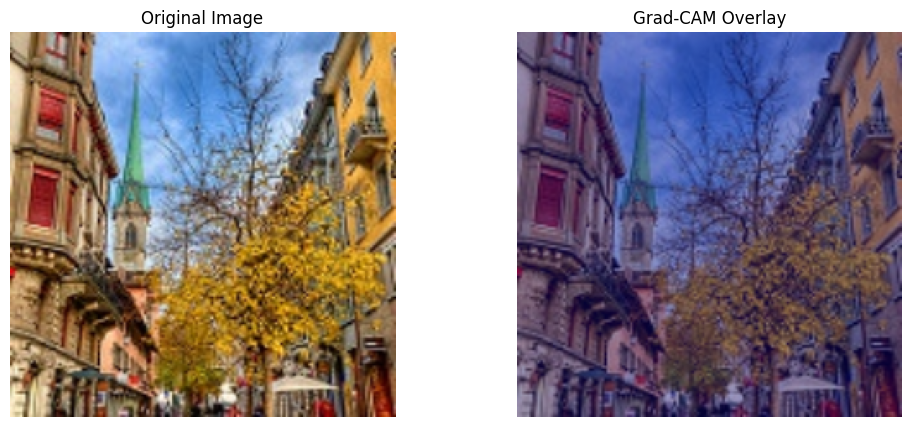

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# IMAGE
img_path = "/content/intel/seg_pred/seg_pred/10004.jpg"

img = tf.keras.preprocessing.image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# PREDICTION
preds = model.predict(img_array)

print("Prediction Vector:")
print(preds)

pred_class = np.argmax(preds[0])

print("Predicted Class:", pred_class)
print("Confidence:", np.max(preds))

# FIND CONV LAYER
for layer in reversed(model.layers):
    try:
        if len(layer.output.shape) == 4:
            last_conv_layer_name = layer.name
            break
    except:
        pass

print("Using Layer:", last_conv_layer_name)

# GRAD MODEL
grad_model = tf.keras.models.Model(
    model.inputs,
    [
        model.get_layer(last_conv_layer_name).output,
        model.output
    ]
)

# GRADIENTS
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    loss = predictions[:, pred_class]

grads = tape.gradient(loss, conv_outputs)

print("Gradient Shape:", grads.shape)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(
    conv_outputs * pooled_grads,
    axis=-1
)

heatmap = heatmap.numpy()

print("Heatmap Min:", np.min(heatmap))
print("Heatmap Max:", np.max(heatmap))

heatmap = np.maximum(heatmap, 0)

if np.max(heatmap) > 0:
    heatmap /= np.max(heatmap)

# DISPLAY HEATMAP
plt.figure(figsize=(6,6))
plt.imshow(heatmap, cmap='jet')
plt.colorbar()
plt.title("Grad-CAM Heatmap")
plt.show()

# OVERLAY
original = cv2.imread(img_path)
original = cv2.resize(original,(224,224))

heatmap = cv2.resize(
    heatmap,
    (224,224)
)

heatmap = np.uint8(
    255 * heatmap
)

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

superimposed = cv2.addWeighted(
    original,
    0.6,
    heatmap,
    0.4,
    0
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.show()

In [ ]:
import tensorflow as tf

print(
    tf.config.list_physical_devices('GPU')
)

[]


In [ ]:
fatal: unable to access 'https://github.com/SUBRAHMANYA2726/SCENESENSE-AI-AIML-PROJECT-.git/': getaddrinfo() thread failed to startimport os

classes = os.listdir(TRAIN_DIR)

for c in classes:

    count = len(
        os.listdir(
            os.path.join(TRAIN_DIR,c)
        )
    )

    print(c, count)

: 

In [ ]:
classes = {
    0: "buildings",
    1: "forest",
    2: "glacier",
    3: "mountain",
    4: "sea",
    5: "street"
}

scene = classes[pred_class]

travel_recommendations = {

    "mountain": {
        "Best Season": "October - February",
        "Activities": "Trekking, Camping, Photography",
        "Safety": "Carry warm clothes and check weather forecasts"
    },

    "forest": {
        "Best Season": "August - January",
        "Activities": "Nature Walks, Wildlife Photography",
        "Safety": "Stay on marked trails and avoid isolated areas"
    },

    "sea": {
        "Best Season": "November - March",
        "Activities": "Swimming, Surfing, Boating",
        "Safety": "Use sunscreen and follow beach safety rules"
    },

    "glacier": {
        "Best Season": "December - March",
        "Activities": "Snow Trekking, Ice Photography",
        "Safety": "Wear thermal clothing and avoid thin ice zones"
    },

    "street": {
        "Best Season": "Year Round",
        "Activities": "City Tours, Food Exploration",
        "Safety": "Follow local traffic and safety regulations"
    },

    "buildings": {
        "Best Season": "Year Round",
        "Activities": "Architecture Photography, Heritage Visits",
        "Safety": "Follow site regulations and visitor guidelines"
    }
}

print("\n========== SceneSense AI ==========\n")

print("Detected Scene :", scene.upper())
print("Confidence     :", round(float(np.max(preds))*100,2), "%")

print("\nTravel Recommendations\n")

for key, value in travel_recommendations[scene].items():
    print(f"{key}: {value}")


========== SceneSense AI ==========

Detected Scene : MOUNTAIN
Confidence     : 17.92 %

Travel Recommendations

Best Season: October - February
Activities: Trekking, Camping, Photography
Safety: Carry warm clothes and check weather forecasts
